Here we do the sensitivity_analysis if the boundary and radius (max distance between two paired points) value. 

Make sure you loaded the right merged_df within CreatingPairedDF.ipynb. (bounardy = (0.01 - 0.04) and radius = (0.01 - 0.03) )

hell yeah


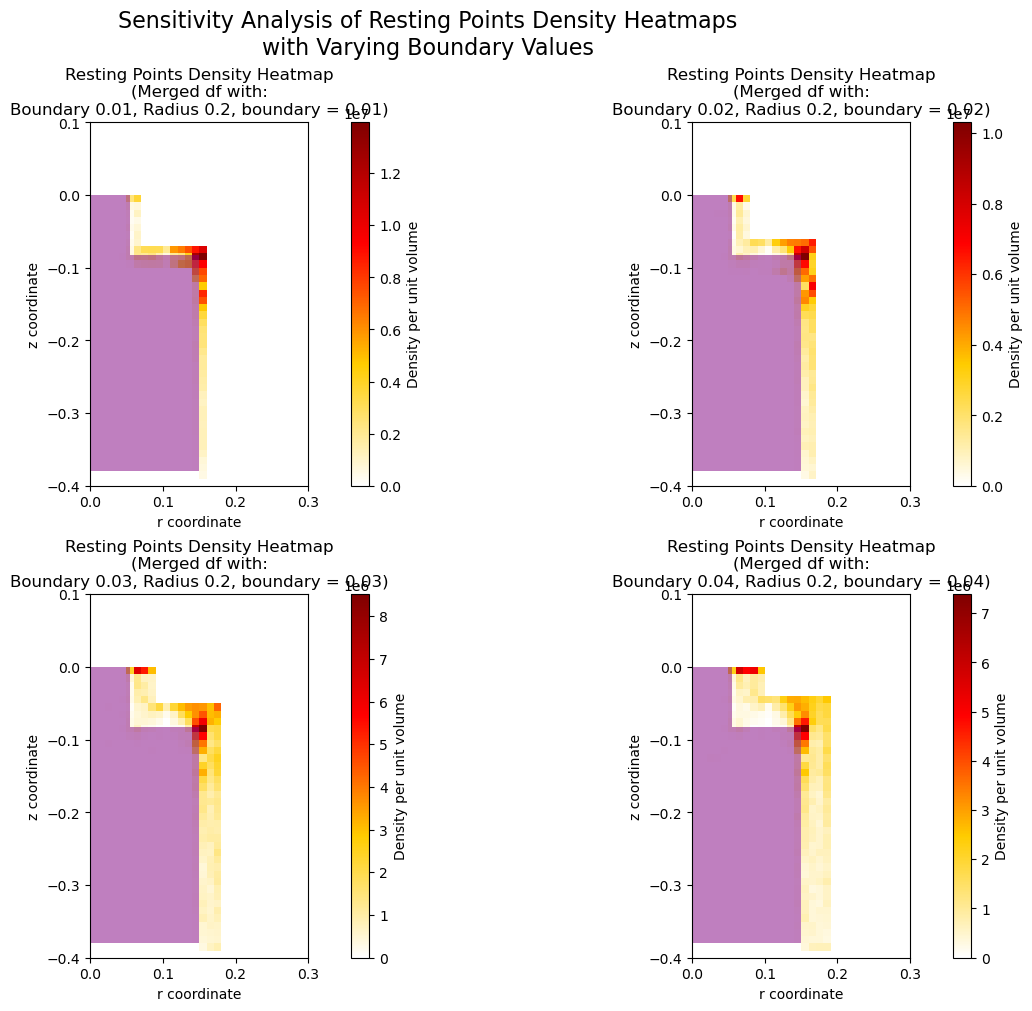

In [8]:
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from CommonFunctions import resting_points, density_matrix_2d_normalized, getTrap2D, plot_density_heatpmap

# boundary sensitivity analysis with different merged_df files (radius  = 0.02)
boundaries = [0.01, 0.02, 0.03, 0.04]
radius2= 0.2
num_trials = 64 # all trials = 64 
matrices= []


for b in boundaries:
    merged_df_path = f'/Users/nubia/Desktop/Thesis_2.0/dataset/merged_df_boundary_{b}_radius_{radius2}.joblib'
    dataset_name = f'Merged df with:\nBoundary {b}, Radius {radius2}'
    merged_df = joblib.load(merged_df_path)
    data = merged_df

    # ======== 1. Get resting points ======== #
    all_x, all_y, all_z = resting_points(data, start_trial_num=1, end_trial_num=num_trials + 1, boundary = b)
    n_restingpoints_boundary =  len(all_x)

    # ======== 2. Compute density matrix ======== #
    density_matrix, r_edges, z_edges = density_matrix_2d_normalized(all_x, all_y, all_z)
    matrices.append((b, density_matrix, r_edges, z_edges))
print("hell yeah") #KLOPT NOG NIEEEEEET 


# VANAF HIER VERDER 
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
colors = [(1, 1, 1), (1, 0.8, 0), (1, 0, 0), (0.5, 0, 0)]
cmap = LinearSegmentedColormap.from_list("custom_red_hot", colors)
inlet_r, inlet_z, body_r, body_z = getTrap2D() 
for i, ax in enumerate(axes.flatten()):
    boundary, density_matrix, r_edges, z_edges = matrices[i]
    # same orientation as plot_density_heatpmap (no transpose)
    im = ax.imshow(
        density_matrix,
        origin='lower',
        aspect='auto',
        extent=[r_edges[0], r_edges[-1], z_edges[0], z_edges[-1]],
        cmap=cmap
    )
    ax.fill(body_r, body_z, color='purple', linewidth=0, alpha=0.5)
    ax.fill(inlet_r, inlet_z, color='purple', linewidth=0, alpha=0.5)
    ax.set_xlim(0, 0.3)
    ax.set_ylim(-0.4, 0.1)
    ax.set_xlabel('r coordinate')
    ax.set_ylabel('z coordinate')
    dataset_name = f'Merged df with:\nBoundary {boundary}, Radius {radius2}'
    ax.set_title(f'Resting Points Density Heatmap\n({dataset_name}, boundary = {boundary})')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(im, ax=ax, label='Density per unit volume')
plt.suptitle('Sensitivity Analysis of Resting Points Density Heatmaps\nwith Varying Boundary Values', fontsize=16)
plt.show()


only one plot

In [ ]:
import joblib
import matplotlib.pyplot as plt
from CommonFunctions import resting_points, density_matrix_2d_normalized, plot_density_heatpmap

# boundary sensitivity analysis with different merged_df files (radius  = 0.02)
boundary = 0.02
radius2= 0.2
num_trials = 64 # all trials = 64 
matrices= []

merged_df_path = f'/Users/nubia/Desktop/Thesis_2.0/dataset/merged_df_boundary_{boundary}_radius_{radius2}.joblib'
dataset_name = f'Merged df with:\nBoundary {boundary}, Radius {radius2}'
merged_df = joblib.load(merged_df_path)
data = merged_df

# ======== 1. Get resting points ======== #
all_x, all_y, all_z = resting_points(data, start_trial_num=1, end_trial_num=num_trials + 1, boundary = boundary)
print("Resting points found:", len(all_x))

# ======== 2. Compute density matrix ======== #
density_matrix, r_edges, z_edges = density_matrix_2d_normalized(all_x, all_y, all_z)
 
# ======== 3. Plot heatmap with trap overlay ======== #
plot_density_heatpmap(density_matrix, r_edges, z_edges, dataset_name = dataset_name, boundary=boundary)